### 1: Mengimpor (Libraries)

In [1]:
# ==========================================
# FASE 3: RANDOM FOREST MODEL TRAINING
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn Modules untuk Pemodelan & Validasi
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, cross_validate
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                             roc_auc_score, confusion_matrix, classification_report, 
                             roc_curve, auc)

# Konfigurasi Visualisasi
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("muted")

print("✅ Pustaka berhasil dimuat!")

✅ Pustaka berhasil dimuat!


### 2: Memuat Data Hasil Optimasi GA (Single Source of Truth)

In [2]:
# Memuat dataset hasil seleksi Algoritma Genetika (GA)
# Pastikan path ini sesuai dengan struktur direktori Anda
file_path = '../dataset/processed/ga_optimized_features_dataset.csv'
df_rf = pd.read_csv(file_path)

print(f"Dimensi Data: {df_rf.shape}")
print(f"Distribusi Target (Mild Imbalance):\n{df_rf['label'].value_counts(normalize=True) * 100}")

# Memisahkan Fitur (X) dan Target (y)
# Catatan: Jika ada kolom metadata (seperti 'url' atau 'type') yang masih terbawa, kita pastikan drop di sini.
kolom_metadata = ['label', 'type', 'url'] 
kolom_drop = [col for col in kolom_metadata if col in df_rf.columns]

X = df_rf.drop(columns=kolom_drop)
y = df_rf['label']

print(f"✅ Data dipisahkan: {X.shape[1]} fitur siap dilatih.")

Dimensi Data: (638564, 47)
Distribusi Target (Mild Imbalance):
label
0    66.770598
1    33.229402
Name: proportion, dtype: float64
✅ Data dipisahkan: 46 fitur siap dilatih.


### 3: Pembagian Data yang Terisolasi (Train-Test Split)

In [3]:
# Train-Test Split (80% Training, 20% Testing)
# stratify=y memastikan rasio Benign vs Malicious identik di kedua set
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y
)

print(f"Jumlah Data Pelatihan (Training): {X_train.shape[0]} baris")
print(f"Jumlah Data Pengujian (Testing) : {X_test.shape[0]} baris")

Jumlah Data Pelatihan (Training): 510851 baris
Jumlah Data Pengujian (Testing) : 127713 baris


### 4: Inisialisasi Model & Stratified 5-Fold Cross-Validation

In [4]:
# 1. Inisialisasi Model dengan penanganan Mild Imbalance (class_weight='balanced')
rf_model = RandomForestClassifier(
    n_estimators=100,      # Jumlah pohon keputusan standar
    max_depth=None,        # Dibiarkan berekspansi hingga node murni
    class_weight='balanced', # Memberikan penalti bobot pada kelas Malicious jika salah tebak
    random_state=42,
    n_jobs=-1              # Memanfaatkan seluruh core CPU (Parallel processing)
)

# 2. Setup Stratified 5-Fold CV
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 3. Eksekusi Cross-Validation dengan metrik berlapis (F1 Macro & Recall)
print("⏳ Menjalankan Stratified 5-Fold Cross Validation...")
cv_results = cross_validate(
    rf_model, X_train, y_train, 
    cv=skf, 
    scoring={'f1_macro': 'f1_macro', 'recall': 'recall'}
)

# 4. Pelaporan Stabilitas Model (Mean & Standard Deviation)
print("\n=== HASIL 5-FOLD CROSS-VALIDATION PADA DATA TRAINING ===")
print(f"F1-Macro Score : {cv_results['test_f1_macro'].mean():.4f} (± {cv_results['test_f1_macro'].std():.4f})")
print(f"Recall (Deteksi): {cv_results['test_recall'].mean():.4f} (± {cv_results['test_recall'].std():.4f})")
print("Catatan: Jika simpangan baku (±) sangat kecil (< 0.01), berarti model sangat stabil dan bebas overfitting.")

⏳ Menjalankan Stratified 5-Fold Cross Validation...

=== HASIL 5-FOLD CROSS-VALIDATION PADA DATA TRAINING ===
F1-Macro Score : 0.9226 (± 0.0004)
Recall (Deteksi): 0.8906 (± 0.0005)
Catatan: Jika simpangan baku (±) sangat kecil (< 0.01), berarti model sangat stabil dan bebas overfitting.


### 5: Pelatihan Akhir & Pengujian pada Data Tidak Terlihat (Unseen Data)

In [5]:
# Melatih model menggunakan seluruh data pelatihan 80%
rf_model.fit(X_train, y_train)

# Melakukan prediksi probabilitas dan kelas pada set pengujian 20%
y_pred = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

# Cetak Laporan Kinerja Klasifikasi (Classification Report)
print("=== CLASSIFICATION REPORT (DATA TESTING) ===\n")
print(classification_report(y_test, y_pred, target_names=['Benign (0)', 'Malicious (1)']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}")

=== CLASSIFICATION REPORT (DATA TESTING) ===

               precision    recall  f1-score   support

   Benign (0)       0.95      0.95      0.95     85275
Malicious (1)       0.90      0.89      0.90     42438

     accuracy                           0.93    127713
    macro avg       0.92      0.92      0.92    127713
 weighted avg       0.93      0.93      0.93    127713

ROC-AUC Score: 0.9761


### 6: Visualisasi (Confusion Matrix, ROC, & Feature Importance)

#### 6.1 Visualisasi Terpisah: Analisis Confusion Matrix

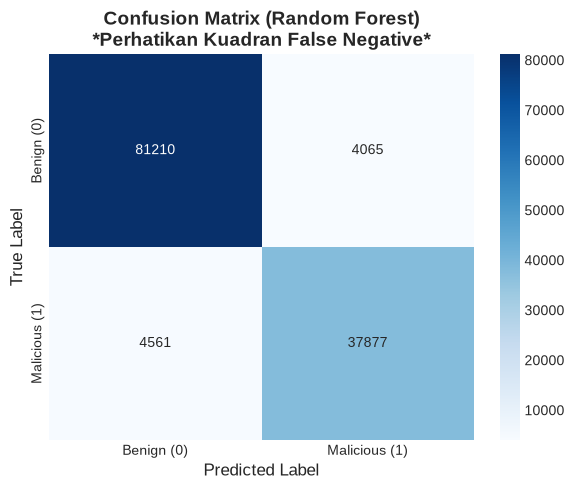

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Pastikan model 'rf_model', 'X_test', dan 'y_test' sudah didefinisikan sebelumnya
y_pred = rf_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

# Membuat kanvas mandiri untuk Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))

# Plot Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['Benign (0)', 'Malicious (1)'], 
            yticklabels=['Benign (0)', 'Malicious (1)'], ax=ax)

# Kustomisasi teks dan judul
ax.set_title('Confusion Matrix (Random Forest)\n*Perhatikan Kuadran False Negative*', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)

plt.tight_layout()
plt.show()

#### 6.2 Visualisasi Terpisah: Kurva ROC (Receiver Operating Characteristic)

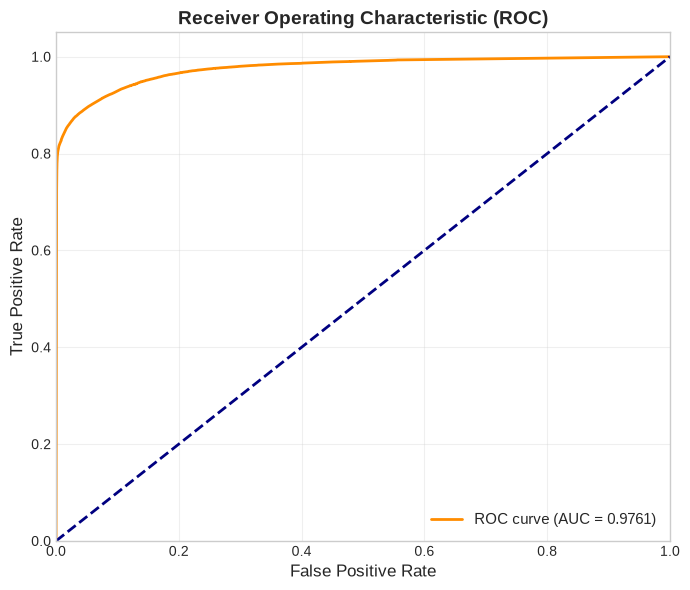

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Pastikan model 'rf_model', 'X_test', dan 'y_test' sudah didefinisikan sebelumnya
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Membuat kanvas mandiri untuk Kurva ROC
fig, ax = plt.subplots(figsize=(7, 6))

# Plot garis ROC dan garis dasar acak (random baseline)
ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

# Kustomisasi rentang dan label grafik
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('Receiver Operating Characteristic (ROC)', fontsize=14, fontweight='bold')
ax.legend(loc="lower right", fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### 6.3 Visualisasi Terpisah: Analisis Feature Importance (Top 10)

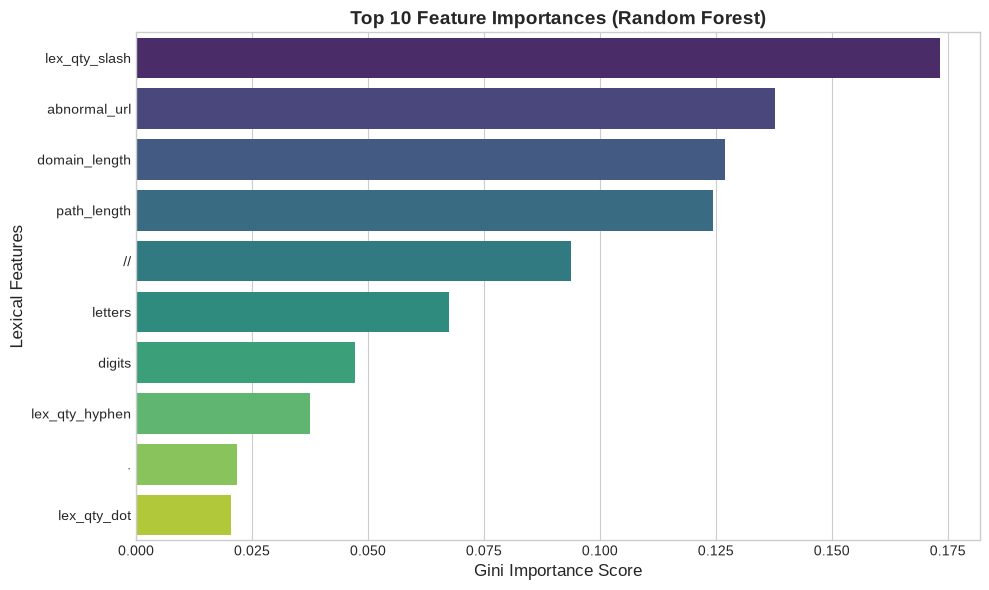

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Pastikan model 'rf_model' dan DataFrame fitur asli 'X' sudah didefinisikan sebelumnya
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1][:10]  # Mengambil 10 peringkat teratas
top_features = X.columns[indices]

# Membuat kanvas mandiri untuk Feature Importance
fig, ax = plt.subplots(figsize=(10, 6))

# Plot Barplot horizontal menggunakan seaborn
sns.barplot(x=importances[indices], y=top_features, palette='viridis', ax=ax)

# Sesuai dengan konfigurasi judul dan sumbu yang Anda minta:
ax.set_title('Top 10 Feature Importances (Random Forest)', fontsize=14, fontweight='bold')
ax.set_xlabel('Gini Importance Score', fontsize=12)
ax.set_ylabel('Lexical Features', fontsize=12)

plt.tight_layout()
plt.show()